In [12]:
import pandas as pd

In [13]:
df = pd.read_csv('listings.csv')


In [14]:
df.head()

,id,name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,11156,An Oasis in the City,40855,1462507354016954190,Colleen,NaN,Sydney,-33.86767,151.22497,Private room,25.0,90.0,193,2020-03-13,0.96,1,363,0,NaN
1,15253,Unique Designer Rooftop Apartment in City Loca...,59850,1462507959673254927,Morag,NaN,Sydney,-33.87964,151.21680,Private room,145.0,1.0,676,2026-06-14,3.88,1,199,58,PID-STRA-24061-7
2,44545,Sunny Darlinghurst Warehouse Apartment,112237,1462509878415092926,Atari,NaN,Sydney,-33.87888,151.21439,Entire home/apt,NaN,3.0,91,2026-06-05,0.48,1,0,9,PID-STRA-74219
3,58506,"Studio Yindi @ Mosman, Sydney",279955,1462514560735292417,John,NaN,Mosman,-33.81748,151.23484,Entire home/apt,240.0,1.0,482,2026-06-09,2.56,1,206,35,PID-STRA-2810
4,68999,A little bit of Sydney - Australia,333581,1462515946291630078,Brian,NaN,Hornsby,-33.72966,151.05226,Private room,135.0,1.0,134,2026-04-25,0.73,1,245,14,PID-STRA-9081


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20573 entries, 0 to 20572
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20573 non-null  int64  
 1   name                            20573 non-null  str    
 2   host_id                         20573 non-null  int64  
 3   host_profile_id                 20573 non-null  int64  
 4   host_name                       20573 non-null  str    
 5   neighbourhood_group             0 non-null      float64
 6   neighbourhood                   20573 non-null  str    
 7   latitude                        20573 non-null  float64
 8   longitude                       20573 non-null  float64
 9   room_type                       20573 non-null  str    
 10  price                           17786 non-null  float64
 11  minimum_nights                  20565 non-null  float64
 12  number_of_reviews               20573 non-n

In [16]:
df = df.drop(columns=['neighbourhood_group']) 


In [17]:
df = df.dropna(subset=['price'])
df = df.dropna(subset=['minimum_nights'])

In [18]:
df.info()

<class 'pandas.DataFrame'>
Index: 17778 entries, 0 to 20572
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              17778 non-null  int64  
 1   name                            17778 non-null  str    
 2   host_id                         17778 non-null  int64  
 3   host_profile_id                 17778 non-null  int64  
 4   host_name                       17778 non-null  str    
 5   neighbourhood                   17778 non-null  str    
 6   latitude                        17778 non-null  float64
 7   longitude                       17778 non-null  float64
 8   room_type                       17778 non-null  str    
 9   price                           17778 non-null  float64
 10  minimum_nights                  17778 non-null  float64
 11  number_of_reviews               17778 non-null  int64  
 12  last_review                     14986 non-null  

In [ ]:
avg_price = df.groupby('neighbourhood')['price'].mean().sort_values(ascending=False)
avg_price

neighbourhood
Pittwater           996.449057
Mosman              931.147826
Woollahra           795.110680
Waverley            577.606081
Hunters Hill        539.933333
Manly               533.088591
Warringah           510.031421
North Sydney        509.848189
Sutherland Shire    454.135076
Randwick            430.990110
Willoughby          417.898833
The Hills Shire     391.435583
Leichhardt          385.298246
Sydney              384.445758
Camden              356.547826
Canada Bay          349.490654
Lane Cove           343.091743
Hornsby             339.563492
Ryde                334.857143
City Of Kogarah     310.619048
Auburn              297.774557
Campbelltown        296.763359
Botany Bay          293.881868
Penrith             293.435780
Fairfield           281.767442
Ku-Ring-Gai         279.285047
Marrickville        260.734146
Liverpool           258.090090
Ashfield            257.263158
Strathfield         256.891473
Burwood             247.492611
Parramatta          240.8

In [23]:
print(avg_price.head(10))
print(avg_price.tail(10))

neighbourhood
Pittwater           996.449057
Mosman              931.147826
Woollahra           795.110680
Waverley            577.606081
Hunters Hill        539.933333
Manly               533.088591
Warringah           510.031421
North Sydney        509.848189
Sutherland Shire    454.135076
Randwick            430.990110
Name: price, dtype: float64
neighbourhood
Ashfield       257.263158
Strathfield    256.891473
Burwood        247.492611
Parramatta     240.887850
Blacktown      237.786517
Rockdale       231.500000
Canterbury     204.515152
Bankstown      197.546154
Holroyd        188.176471
Hurstville     180.432203
Name: price, dtype: float64


<Axes: title={'center': 'Top 10 Most Expensive Sydney Suburbs (Avg. Price/Night)'}, xlabel='neighbourhood'>

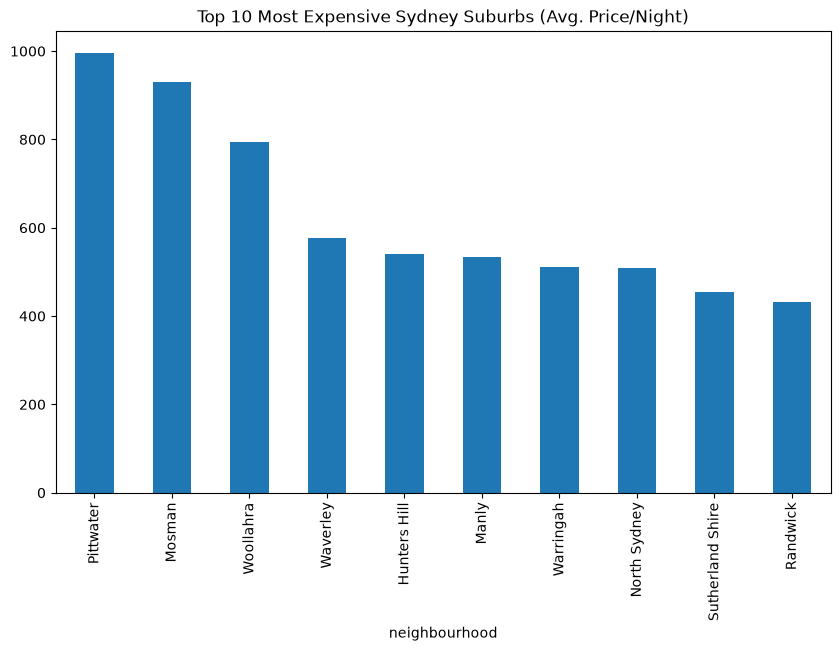

In [24]:
import matplotlib.pyplot as plt
top10 = avg_price.head(10)
top10.plot(kind='bar', figsize=(10,6), title='Top 10 Most Expensive Sydney Suburbs (Avg. Price/Night)')

Does room type affect price?

In [25]:
room_price = df.groupby('room_type')['price'].mean().sort_values(ascending=False)
print(room_price) 

room_type
Entire home/apt    515.510200
Hotel room         204.215686
Private room       138.661749
Shared room         77.076923
Name: price, dtype: float64


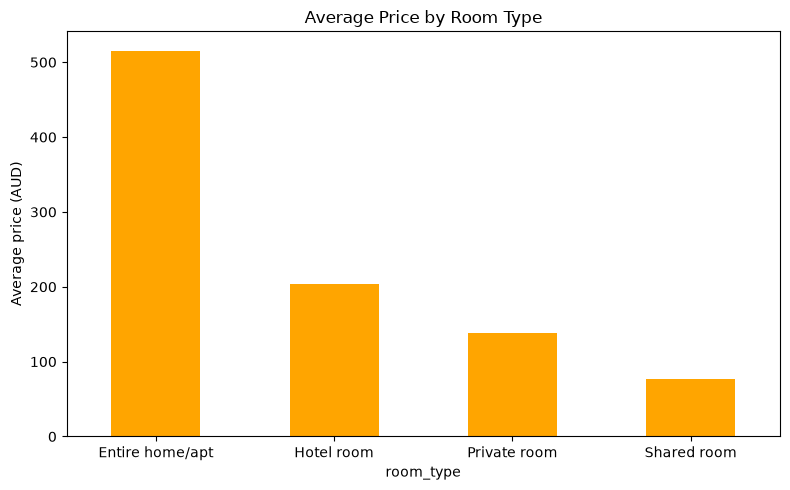

In [31]:
room_price.plot(kind='bar', figsize=(8,5), title='Average Price by Room Type', color='orange')
plt.ylabel('Average price (AUD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()